# Bài tập 3 — Phân tích khám phá dữ liệu (EDA)

**Người phụ trách:** Nguyễn Thị Trâm, Trần Thị Ngọc Ánh (biểu đồ) · Lê Anh Duy, Văn Tường Vy (insight)

---

## Mục tiêu

- Vẽ **≥8 biểu đồ** chuyên nghiệp, mỗi biểu đồ có diễn giải
- Rút ra **5–7 insight** chính

## Hai câu hỏi nghiên cứu cần trả lời

1. Những **yếu tố nào** giúp đưa ra mức giá tham chiếu đáng tin?
2. Sau khi xem xét diện tích và loại nhà, **khu vực nào** bị định giá quá cao/thấp?

In [1]:
# Thiết lập đường dẫn để import được module src/
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
print('done')

done


In [2]:
from src.utils import doc_config, duong_dan_goc

cfg = doc_config()
file_sach = duong_dan_goc() / cfg['duong_dan']['du_lieu_sach'] / 'du_lieu_sach.csv'

df = pd.read_csv(file_sach)
print(f"Đã đọc {len(df):,} dòng")
df.head()

Đã đọc 29,532 dòng


,tieu_de,gia_ban_trieu,dien_tich_m2,tinh_thanh,quan_huyen,phuong_xa,mo_ta_dac_diem,loai_hinh,nguon_du_lieu,url,gia_moi_m2_trieu
0,"Bán căn hộ 2PN 2WC 74,8m2 full NT The Sun Aven...",7000.0,74.8,TP. Hồ Chí Minh,NaN,NaN,"Căn hộ chung cư tại The Sun Avenue, Mai Chí Th...",Can ho,cafeland,https://nhadat.cafeland.vn/ban-can-ho-2pn-2wc-...,93.582888
1,Bán nhà riêng: KINH DƯƠNG VƯƠNG–NHÀ MỚI 2 MẶT ...,7600.0,64.0,TP. Hồ Chí Minh,NaN,NaN,"Bán nhà riêng An Lạc, TP. Hồ Chí Minh Một căn ...",Nha rieng,cafeland,https://nhadat.cafeland.vn/ban-nha-rieng-kinh-...,118.750000
2,Bán nhà riêng: MẶT TIỀN KINH DOANH ĐỈNH – KHU ...,8800.0,76.0,TP. Hồ Chí Minh,NaN,NaN,"Bán nhà riêng An Lạc, TP. Hồ Chí Minh MẶT TIỀN...",Nha rieng,cafeland,https://nhadat.cafeland.vn/ban-nha-rieng-mat-t...,115.789474
3,Bán nhà riêng: SIÊU TỐC – NHÀ ĐẸP FULL NỘI THẤ...,7300.0,56.0,TP. Hồ Chí Minh,NaN,NaN,"Bán nhà riêng Đường số 7, An Lạc, TP. Hồ Chí M...",Nha rieng,cafeland,https://nhadat.cafeland.vn/ban-nha-rieng-sieu-...,130.357143
4,Bán nhà riêng: Bán Nhà riêng 80m2 thổ cư giá 5...,5300.0,80.0,TP. Hồ Chí Minh,NaN,NaN,"Bán nhà riêng An Lạc, TP. Hồ Chí Minh Giá : 5....",Nha rieng,cafeland,https://nhadat.cafeland.vn/ban-nha-rieng-ban-n...,66.250000


## 1. Vẽ toàn bộ 8 biểu đồ

Biểu đồ được lưu vào `reports/figures/`.


VẼ 8 BIỂU ĐỒ CHO PHẦN EDA


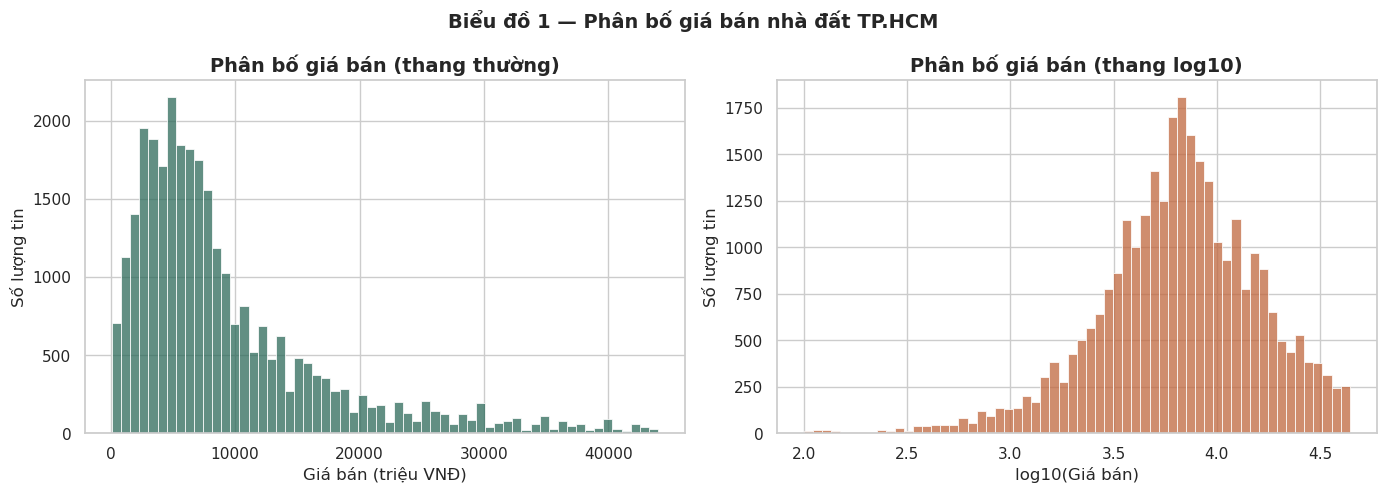

  ✅ bd01_phan_bo_gia.png


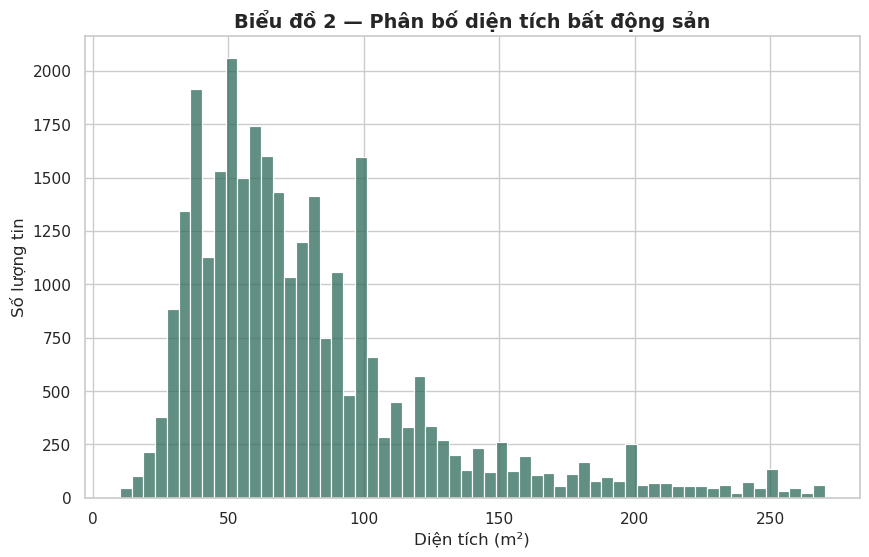

  ✅ bd02_phan_bo_dien_tich.png


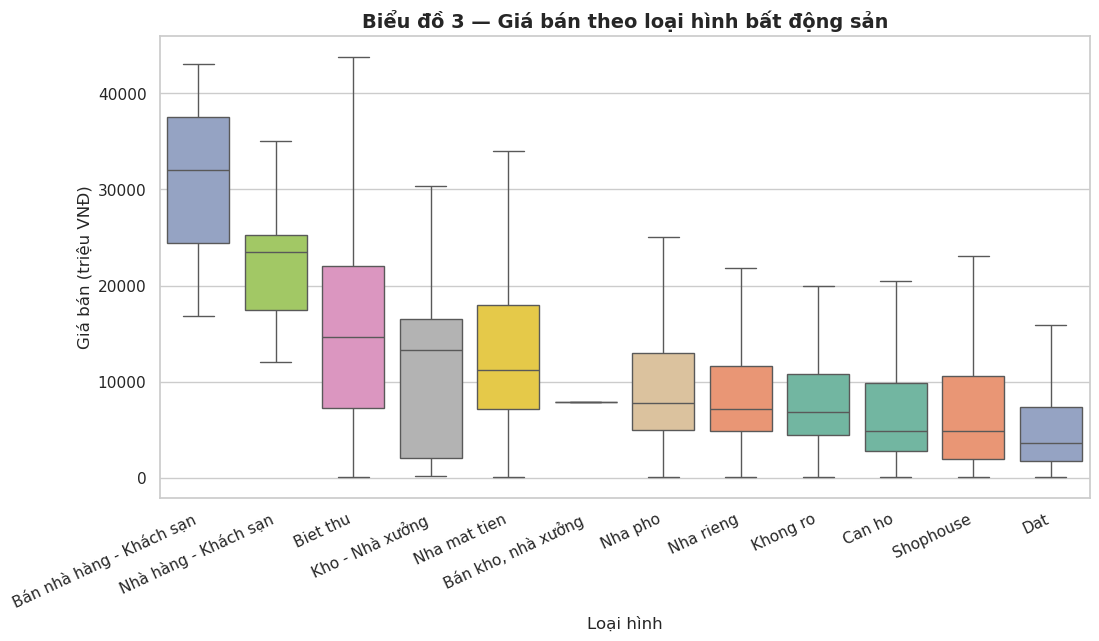

  ✅ bd03_gia_theo_loai_hinh.png


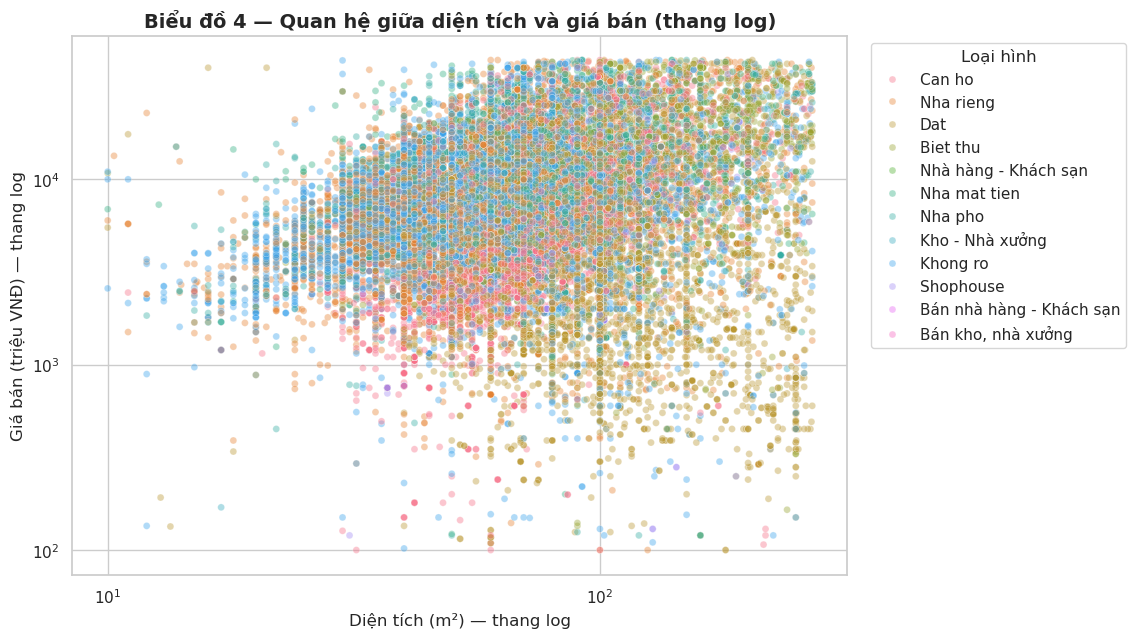

  ✅ bd04_tuong_quan_dien_tich_gia.png
  ⚠️  Bỏ qua bd05: không có dữ liệu quận/huyện


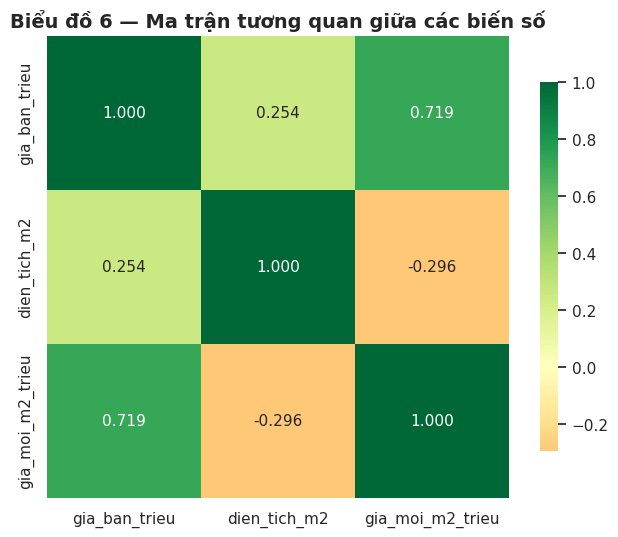

  ✅ bd06_ma_tran_tuong_quan.png


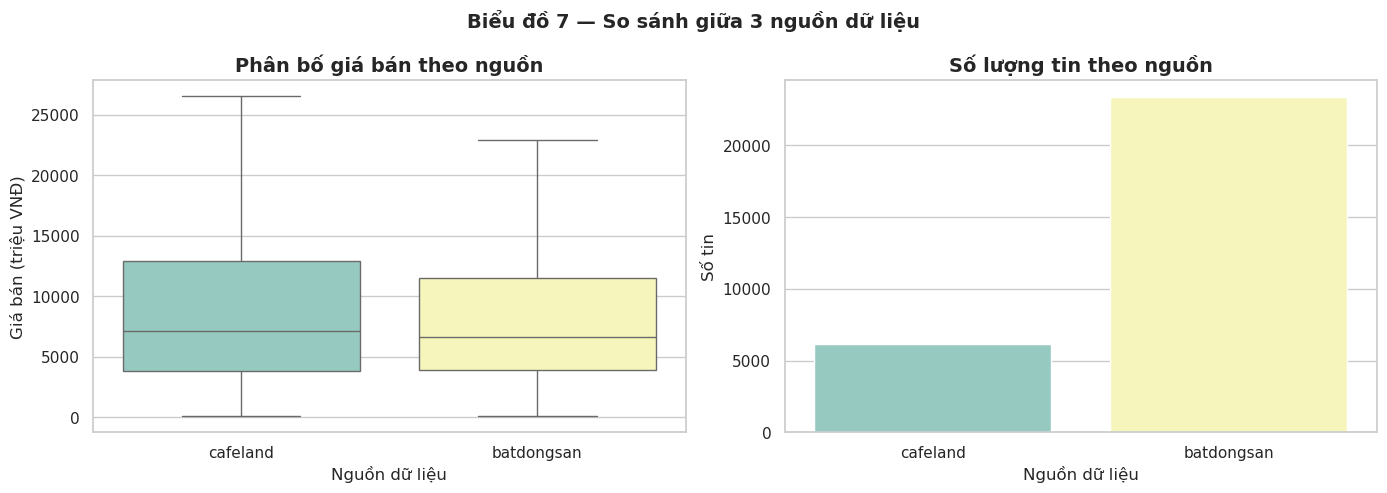

  ✅ bd07_so_sanh_nguon.png


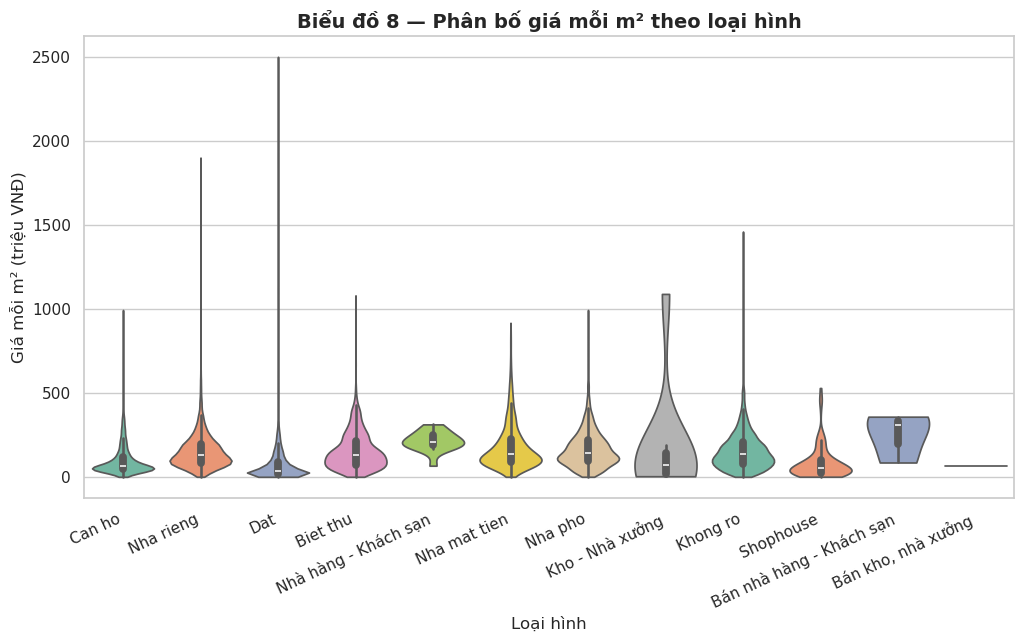

  ✅ bd08_gia_m2_theo_loai_hinh.png

✅ Biểu đồ đã lưu tại: C:\Users\hatro\Downloads\du-doan-gia-nha-dat-hcm-HuuDuy-s-Branch\du-doan-gia-nha-dat-hcm\reports\figures


In [3]:
from src.visualization.ve_bieu_do import ve_tat_ca

ve_tat_ca(df)

## 2. Xem từng biểu đồ và viết diễn giải

### Biểu đồ 1 — Phân bố giá bán

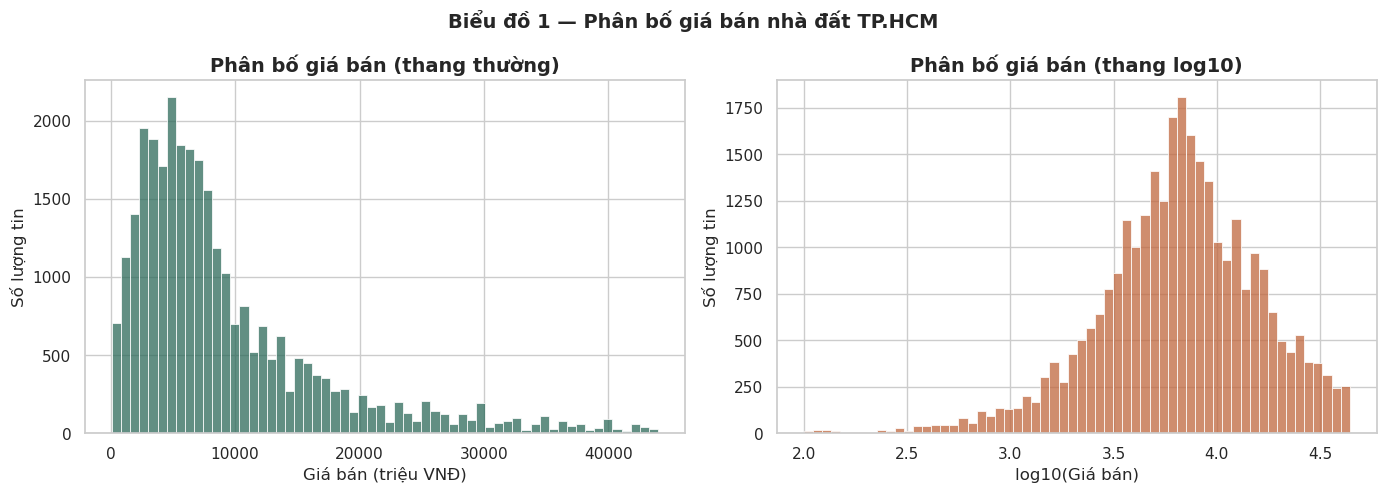

  ✅ bd01_phan_bo_gia.png


In [4]:
from src.visualization.ve_bieu_do import thiet_lap_style, bd01_phan_bo_gia
from pathlib import Path
import matplotlib.pyplot as plt
thiet_lap_style(cfg)
thu_muc_hinh = duong_dan_goc() / cfg['duong_dan']['bieu_do']
bd01_phan_bo_gia(df, thu_muc_hinh)

**Diễn giải biểu đồ 1:**

*(Viết nhận xét: phân phối lệch phải hay trái? Vì sao? Điều này ảnh hưởng gì đến việc chọn mô hình?)*
Phân phối giá bán có hiện tượng lệch phải do một số lượng nhỏ bất động sản có giá trị rất cao. Đặc điểm này có thể ảnh hưởng đến các mô hình nhạy cảm với phân phối dữ liệu và các giá trị cực đoan. Vì vậy, biến giá có thể được biến đổi logarit khi sử dụng các mô hình phù hợp, trong khi các mô hình dựa trên cây quyết định như Random Forest hoặc Gradient Boosting thường ít nhạy cảm hơn với hiện tượng lệch của biến đầu vào.

### Biểu đồ 4 — Quan hệ diện tích ↔ giá bán

Đây là biểu đồ then chốt cho **Câu hỏi 1**.

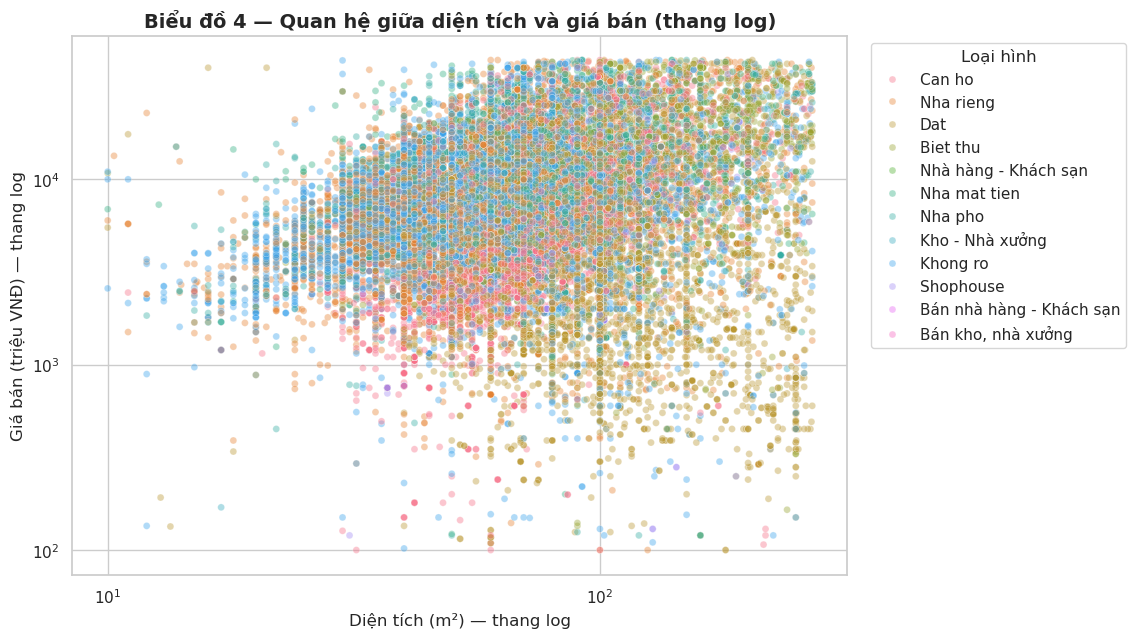

  ✅ bd04_tuong_quan_dien_tich_gia.png


In [5]:
from src.visualization.ve_bieu_do import bd04_tuong_quan_dien_tich_gia

bd04_tuong_quan_dien_tich_gia(df, thu_muc_hinh)

**Diễn giải biểu đồ 4:**

*(Diện tích có tương quan mạnh với giá không? Quan hệ tuyến tính hay phi tuyến?)*

### Biểu đồ 5 — Giá theo quận/huyện

Đây là biểu đồ then chốt cho **Câu hỏi 2**.

In [ ]:
from src.visualization.ve_bieu_do import bd05_top_quan_huyen

bd05_top_quan_huyen(df, thu_muc_hinh)

**Diễn giải biểu đồ 5:**

*(Quận nào đắt nhất/rẻ nhất? Chênh lệch bao nhiêu lần?)*

## 3. Năm đến bảy insight chính

> **Lưu ý:** insight ≠ mô tả biểu đồ. Insight phải nêu được **ý nghĩa thực tế** và **hàm ý hành động**.

### Insight 1
*(Ví dụ: "Diện tích giải thích được X% biến thiên giá, nhưng riêng nó chưa đủ — hai BĐS cùng 80m² có thể chênh nhau N lần tùy quận.")*

### Insight 2

### Insight 3

### Insight 4

### Insight 5